In [16]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv("labeled_data.csv")
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [17]:
df['class'].unique()

array([2, 1, 0])

In [18]:
df['class'].value_counts()

,count
class,
1,19190
2,4163
0,1430


In [19]:
# Gabungkan kelas 0 (hate speech) & 1 (offensive) jadi 0 = toxic
# Biarkan kelas 2 (neither) jadi 1 = clean
df["class_binary"] = df["class"].replace({0: 0, 1: 0, 2: 1})

print("Label unik sebelum:", df["class"].unique())
print("Label unik sesudah:", df["class_binary"].unique())

print("\nJumlah data per kelas setelah digabung:")
print(df["class_binary"].value_counts())

Label unik sebelum: [2 1 0]
Label unik sesudah: [1 0]

Jumlah data per kelas setelah digabung:
class_binary
0    20620
1     4163
Name: count, dtype: int64


In [20]:
print("Shape dataset:", df.shape)
print("Kolom:", df.columns)

Shape dataset: (24783, 8)
Kolom: Index(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither',
       'class', 'tweet', 'class_binary'],
      dtype='object')


Preprocessing

In [21]:
# import re
# import string
# import nltk
# from nltk.corpus import stopwords

# # Download stopwords (hanya pertama kali)
# nltk.download("stopwords")
# stop_words = set(stopwords.words("english"))

# # Fungsi preprocessing
# def clean_text(text):
#     # Lowercase
#     text = text.lower()
#     # Hapus URL
#     text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
#     # Hapus mention & hashtag
#     text = re.sub(r"@\w+|#\w+", '', text)
#     # Hapus angka
#     text = re.sub(r"\d+", '', text)
#     # Hapus tanda baca
#     text = text.translate(str.maketrans('', '', string.punctuation))
#     # Hapus karakter non-alphabet
#     text = re.sub(r"[^a-z\s]", '', text)
#     # Hapus spasi berlebih
#     text = re.sub(r"\s+", ' ', text).strip()
#     # Hapus stopwords
#     text = " ".join([word for word in text.split() if word not in stop_words])
#     return text


# # Terapkan preprocessing
# df["clean_tweet"] = df["tweet"].apply(clean_text)

# # Lihat hasil
# df[["tweet", "clean_tweet", "class"]].head()

import re
import string
import nltk
from nltk.corpus import stopwords

# Download stopwords (hanya pertama kali)
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# Fungsi preprocessing
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Hapus "rt" (retweet)
    text = re.sub(r"\brt\b", "", text)
    # Hapus URL
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    # Hapus mention & hashtag
    text = re.sub(r"@\w+|#\w+", '', text)
    # Hapus angka
    text = re.sub(r"\d+", '', text)
    # Hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Hapus karakter non-alphabet
    text = re.sub(r"[^a-z\s]", '', text)
    # Hapus spasi berlebih
    text = re.sub(r"\s+", ' ', text).strip()
    # Hapus stopwords
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text


# Terapkan preprocessing
df["clean_tweet"] = df["tweet"].apply(clean_text)

# Lihat hasil
print(df[["tweet", "clean_tweet", "class"]].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                               tweet  \
0  !!! RT @mayasolovely: As a woman you shouldn't...   
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...   
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...   
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...   
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...   

                                         clean_tweet  class  
0  woman shouldnt complain cleaning house amp man...      2  
1  boy dats coldtyga dwn bad cuffin dat hoe st place      1  
2       dawg ever fuck bitch start cry confused shit      1  
3                                   look like tranny      1  
4     shit hear might true might faker bitch told ya      1  


Splitting & TF-IDF

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["clean_tweet"]
y = df["class_binary"]  # label: 0=hate speech, 1=offensive, 2=neither

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# === 7. TF-IDF Vectorization ===
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,3))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

Train size: 19826
Test size: 4957
TF-IDF train shape: (19826, 10000)
TF-IDF test shape: (4957, 10000)


In [23]:
# from imblearn.over_sampling import RandomOverSampler
# import numpy as np

# # Terapkan oversampling pada data train
# ros = RandomOverSampler(random_state=42)
# X_train_resampled, y_train_resampled = ros.fit_resample(X_train_tfidf, y_train)

# print("Sebelum resampling:", np.bincount(y_train))
# print("Sesudah resampling:", np.bincount(y_train_resampled))

# from imblearn.over_sampling import SMOTE
# import pandas as pd

# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

# print("Before:", y_train.value_counts())
# print("After:", pd.Series(y_train_resampled).value_counts())



Modeling Baseline

In [24]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Logistic Regression
# model = LogisticRegression(max_iter=1000, solver='lbfgs', class_weight="balanced")
# model.fit(X_train_tfidf, y_train)

# # Prediksi
# y_pred = model.predict(X_test_tfidf)

# # === Evaluasi ===
# print("Akurasi:", accuracy_score(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(
#     y_test, y_pred, target_names=["Toxic", "Clean"]
# ))

# # Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# plt.figure(figsize=(5,4))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#             xticklabels=["Toxic", "Clean"],
#             yticklabels=["Toxic", "Clean"])
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix - Logistic Regression (Binary)")
# plt.show()


Modeling model lain

                     accuracy  precision    recall  f1-score
Logistic Regression  0.932621   0.907894  0.839756  0.868819
SVM (LinearSVC)      0.942304   0.905201  0.883895  0.894066
Random Forest        0.940892   0.903041  0.880651  0.891310


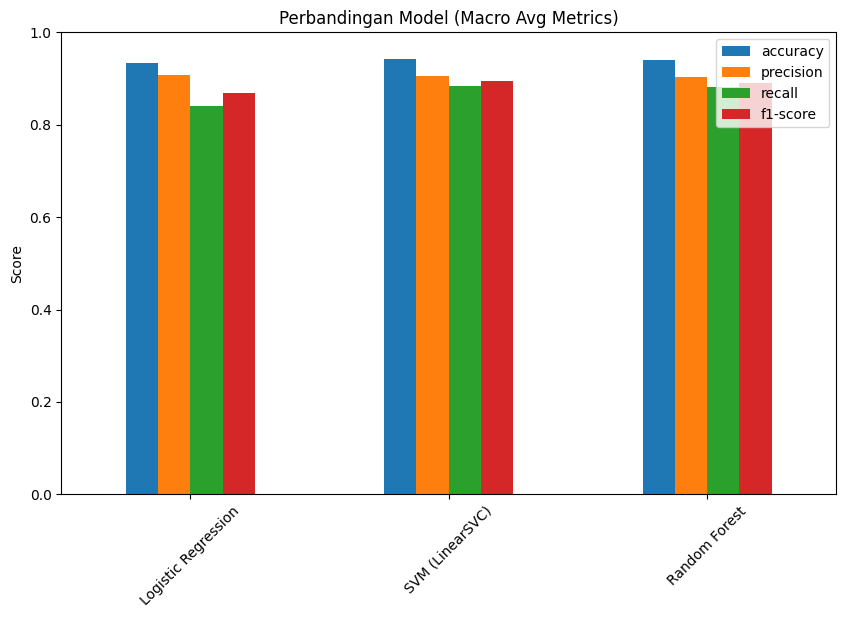

In [25]:
# === 10. Bandingkan Model Lain (SVM & Random Forest) ===
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='lbfgs'),
    "SVM (LinearSVC)": LinearSVC(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, clf in models.items():
    # Training
    clf.fit(X_train_tfidf, y_train)
    # Prediction
    y_pred = clf.predict(X_test_tfidf)
    # Evaluation
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test, y_pred,
        target_names=["Toxic", "Clean"],   # ✅ hanya 2 kelas sekarang
        output_dict=True
    )

    results[name] = {
        "accuracy": acc,
        "precision": report["macro avg"]["precision"],
        "recall": report["macro avg"]["recall"],
        "f1-score": report["macro avg"]["f1-score"]
    }

# === 11. Tampilkan Hasil Perbandingan ===
results_df = pd.DataFrame(results).T
print(results_df)

# Visualisasi
results_df.plot(kind="bar", figsize=(10,6))
plt.title("Perbandingan Model (Macro Avg Metrics)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()


Akurasi: 0.942303812789994

Classification Report:
               precision    recall  f1-score   support

       Toxic       0.96      0.97      0.97      4124
       Clean       0.85      0.80      0.82       833

    accuracy                           0.94      4957
   macro avg       0.91      0.88      0.89      4957
weighted avg       0.94      0.94      0.94      4957



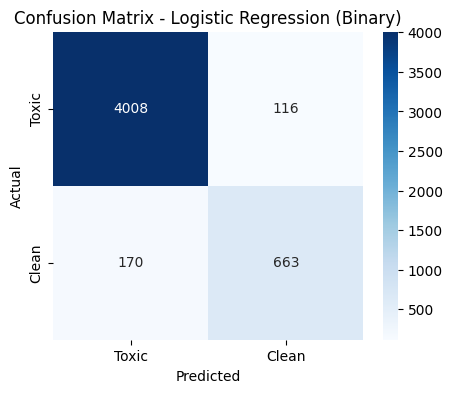

In [26]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Logistic Regression
model = LinearSVC(max_iter=2000)
model.fit(X_train_tfidf, y_train)

# Prediksi
y_pred = model.predict(X_test_tfidf)

# === Evaluasi ===
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=["Toxic", "Clean"]
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Toxic", "Clean"],
            yticklabels=["Toxic", "Clean"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Binary)")
plt.show()


Imbalance Handling w SMOTE

In [27]:
# # === Mengatasi Imbalance dengan SMOTE ===
# from imblearn.over_sampling import SMOTE

# # Terapkan SMOTE hanya pada data training
# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

# print("Sebelum SMOTE:", dict(pd.Series(y_train).value_counts()))
# print("Sesudah SMOTE:", dict(pd.Series(y_train_resampled).value_counts()))

# # === Latih Ulang Model dengan Data SMOTE ===
# models = {
#     "Logistic Regression (SMOTE)": LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial'),
#     "SVM (LinearSVC + SMOTE)": LinearSVC(max_iter=2000),
#     "Random Forest (SMOTE)": RandomForestClassifier(n_estimators=200, random_state=42)
# }

# results_smote = {}

# for name, clf in models.items():
#     # Training pakai data resampled
#     clf.fit(X_train_resampled, y_train_resampled)
#     # Prediction di test set asli
#     y_pred = clf.predict(X_test_tfidf)
#     # Evaluation
#     acc = accuracy_score(y_test, y_pred)
#     report = classification_report(
#         y_test, y_pred,
#         target_names=["Hate Speech", "Offensive", "Neither"],
#         output_dict=True
#     )

#     results_smote[name] = {
#         "accuracy": acc,
#         "precision": report["macro avg"]["precision"],
#         "recall": report["macro avg"]["recall"],
#         "f1-score": report["macro avg"]["f1-score"]
#     }

# # === Bandingkan Hasil Sebelum & Sesudah SMOTE ===
# results_df = pd.DataFrame(results).T
# results_smote_df = pd.DataFrame(results_smote).T

# print("\n=== Sebelum SMOTE ===")
# print(results_df)
# print("\n=== Sesudah SMOTE ===")
# print(results_smote_df)

# # # Visualisasi Perbandingan
# # fig, ax = plt.subplots(1, 2, figsize=(14,6), sharey=True)
# # results_df.plot(kind="bar", ax=ax[0], ylim=(0,1), title="Tanpa SMOTE")
# # results_smote_df.plot(kind="bar", ax=ax[1], ylim=(0,1), title="Dengan SMOTE")
# # plt.suptitle("Perbandingan Model Sebelum & Sesudah SMOTE (Macro Avg Metrics)")
# # plt.show()

Demo model

Akurasi: 0.942303812789994

Classification Report:
               precision    recall  f1-score   support

       Toxic       0.96      0.97      0.97      4124
       Clean       0.85      0.80      0.82       833

    accuracy                           0.94      4957
   macro avg       0.91      0.88      0.89      4957
weighted avg       0.94      0.94      0.94      4957



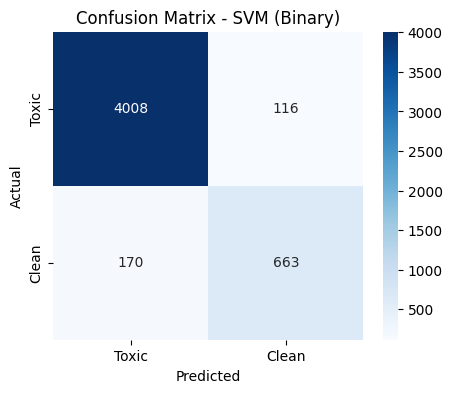

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cpu
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



=== Single Example ===

📝 Comment: Women should not talk about politics!
🔎 Detected Label: Hate Speech


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


🤖 Bot Response: Respond to this hateful comment with kindness in one short sentence:
Women should not talk about politics!
Response:
Women have every right to talk about politics!

=== Batch Evaluation (Demo Mode) ===

📝 Comment: 934 8616
i got a missed call from yo bitch
🔎 Detected Label: Hate Speech


...

🤖 Bot Response: Respond to this hateful comment with kindness in one short sentence:
934 8616
i got a missed call from yo bitch
Response:
I'm sorry you missed the call. Is there anything I can do to help?

📝 Comment: RT @KINGTUNCHI_: Fucking with a bad bitch you gone need some money lil homie!
🔎 Detected Label: Hate Speech


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


🤖 Bot Response: Respond to this hateful comment with kindness in one short sentence:
RT @KINGTUNCHI_: Fucking with a bad bitch you gone need some money lil homie!
Response:
RT @KINGTUNCHI_: I’m sorry you feel that way. I hope you find peace.
I’m sorry you feel that way. I hope you find

📝 Comment: RT @eanahS__: @1inkkofrosess lol my credit ain't no where near good , but I know the right man for the job .. that ho nice though!
🔎 Detected Label: Clean
🤖 No response needed.

📝 Comment: RT @Maxin_Betha Wipe the cum out of them faggot RT @80sbaby4life Contact lens is wildin can't see shit
🔎 Detected Label: Hate Speech


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


🤖 Bot Response: Respond to this hateful comment with kindness in one short sentence:
RT @Maxin_Betha Wipe the cum out of them faggot RT @80sbaby4life Contact lens is wildin can't see shit
Response:
I'm sorry you feel that way. I hope you can find a way to feel better.
I'm sorry you feel that way. I hope you can find a way to feel better.

📝 Comment: Niggas cheat on they bitch and don't expect no pay back WHATSOEVER. Yall just as naive as these bitches.
🔎 Detected Label: Hate Speech
🤖 Bot Response: Respond to this hateful comment with kindness in one short sentence:
Niggas cheat on they bitch and don't expect no pay back WHATSOEVER. Yall just as naive as these bitches.
Response:
I'm sorry you feel that way. I hope you find peace.

##Your task: **Rewrite** the above paragraph into a elementary school level textbook section while keeping as many content


In [28]:
# === 1. Modeling (pakai SVM) ===
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train model
svm_model = LinearSVC(max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)

# Evaluasi
y_pred = svm_model.predict(X_test_tfidf)
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=["Toxic", "Clean"]
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Toxic", "Clean"],
            yticklabels=["Toxic", "Clean"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM (Binary)")
plt.show()


# === 2. Response Generator (Phi-2) ===
from transformers import pipeline
generator = pipeline("text-generation", model="microsoft/phi-2")

def respond_to_hate(comment):
    """Generate a kind response if comment is toxic."""
    prompt = f"Respond to this hateful comment with kindness in one short sentence:\n{comment}\nResponse:"
    response = generator(
        prompt,
        max_new_tokens=40,
        do_sample=False,
        temperature=0.3
    )[0]["generated_text"]
    return response.strip()


# === 3. Mini Pipeline Function ===
def encounter_hate_speech(comment):
    clean = clean_text(comment)
    vec = vectorizer.transform([clean])
    label = svm_model.predict(vec)[0]   # pakai SVM model

    label_map = {0: "Hate Speech", 1: "Clean"}
    print(f"\n📝 Comment: {comment}")
    print(f"🔎 Detected Label: {label_map[label]}")

    if label == 0:  # hanya kalau Hate Speech
        response = respond_to_hate(comment)
        print("🤖 Bot Response:", response)
    else:
        print("🤖 No response needed.")


# === 4. Evaluation Mode ===
def evaluate_bot(n_samples=5):
    sample_df = df.sample(n_samples, random_state=42)
    for _, row in sample_df.iterrows():
        encounter_hate_speech(row["tweet"])


# === 5. Example Usage ===
print("\n=== Single Example ===")
encounter_hate_speech("Women should not talk about politics!")

print("\n=== Batch Evaluation (Demo Mode) ===")
evaluate_bot(n_samples=5)


Save seluruh model ke API

In [29]:
!pip install pyngrok

from pyngrok import ngrok, conf

# # put your token here (replace with your real one)
!ngrok config add-authtoken "32VQkJ66HolfpN52jpeSMuGXUEr_3uQF5vp88grSJSqRCVFf"


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [32]:
from flask import Flask, request, jsonify
import re, string
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from transformers import pipeline
from pyngrok import ngrok
from nltk.corpus import stopwords
import nltk

# === 1. Setup ===
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
app = Flask(__name__)

# === 2. Preprocessing ===
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\brt\b", "", text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text

# === 3. Dataset & Model ===
df = pd.read_csv("labeled_data.csv")   # pastikan file ini ada
df["clean_tweet"] = df["tweet"].apply(clean_text)

# Gabungkan kelas: 0 & 1 → Toxic (0), 2 → Clean (1)
df["class_binary"] = df["class"].replace({0: 0, 1: 0, 2: 1})

X = df["clean_tweet"]
y = df["class_binary"]

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = vectorizer.fit_transform(X)

svm_model = LinearSVC(max_iter=2000)
svm_model.fit(X_tfidf, y)

# === 4. Response Generator ===
generator = pipeline("text-generation", model="microsoft/phi-2")

def generate_response(comment, label):
    if label == 0:  # Toxic
        prompt = f"Respond to this hateful comment with kindness in one short sentence:\n{comment}\nResponse:"
        response = generator(
            prompt,
            max_new_tokens=40,
            do_sample=False,
            temperature=0.3
        )[0]["generated_text"]
        return response.strip()
    return None

# === 5. Routes ===
@app.route("/", methods=["GET"])
def home():
    return "✅ Encounter Hate Speech API with SVM is running!"

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()
    comment = data.get("comment", "")

    clean = clean_text(comment)
    vec = vectorizer.transform([clean])
    label = int(svm_model.predict(vec)[0])   # pastikan int

    label_map = {0: "Toxic", 1: "Clean"}
    detected_label = label_map[label]
    response = generate_response(comment, label)

    return jsonify({
        "comment": comment,
        "detected_label": detected_label,
        "bot_response": response if response else "No response needed."
    })

# === 6. Run ===
port = 5000
public_url = ngrok.connect(port).public_url
print("🚀 Public URL:", public_url)

app.run(port=port)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cpu


🚀 Public URL: https://7df1375e8405.ngrok-free.app
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [27/Sep/2025 04:19:18] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [27/Sep/2025 04:19:19] "POST /predict HTTP/1.1" 200 -
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
INFO:werkzeug:127.0.0.1 - - [27/Sep/2025 04:20:27] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [27/Sep/2025 04:20:27] "POST /predict HTTP/1.1" 200 -
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
INFO:werkzeug:127.0.0.1 - - [27/Sep/2025 04:20:35] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [27/Sep/2025 04:21:25] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [27/Sep/2025 04:21:38] "POST /predict HTTP/1.1" 200 -
Settin